In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set plot style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:

import pandas as pd

print("Loading Flavor-Network Data...")


ingr_df = pd.read_csv('../data/ingr_info.tsv', sep='\t', header=None, names=['ingredient_name', 'category'])
comp_df = pd.read_csv('../data/comp_info.tsv', sep='\t', header=None, names=['compound_name', 'cas_number'])
edges_df = pd.read_csv('../data/ingr_comp.tsv', sep='\t', header=None, names=['ingredient_id', 'compound_id'])


ingr_df['ingredient_id'] = ingr_df.index.astype(str)
comp_df['compound_id'] = comp_df.index.astype(str)


edges_df['ingredient_id'] = edges_df['ingredient_id'].astype(str).str.strip()
edges_df['compound_id'] = edges_df['compound_id'].astype(str).str.strip()

print(f"Flavor-Network Loaded: {len(ingr_df)} Ingredients, {len(comp_df)} Compounds, {len(edges_df)} Connections.")

Loading Flavor-Network Data...
Flavor-Network Loaded: 1531 Ingredients, 1108 Compounds, 36782 Connections.


In [3]:
print("\nLoading FooDB Data...")


foodb_foods = pd.read_csv('../data/Food.csv', usecols=['id', 'name', 'food_group'])
foodb_compounds = pd.read_csv('../data/Compound.csv', usecols=['id', 'public_id', 'name'])

print(f"FooDB Loaded: {len(foodb_foods)} Foods, {len(foodb_compounds)} Nutrients/Compounds.")


Loading FooDB Data...
FooDB Loaded: 992 Foods, 70477 Nutrients/Compounds.



Top 10 Most Flavor-Complex Ingredients:


,ingredient_name,category,compound_count
1424,black_tea,plant derivative,239
1117,coffee,plant derivative,234
979,bantu_beer,alcoholic beverage,230
550,beer,alcoholic beverage,227
476,white_wine,alcoholic beverage,222
818,grilled_beef,meat,217
704,roasted_beef,meat,216
1110,boiled_beef,meat,206
1479,fried_beef,meat,204
693,beef,meat,199


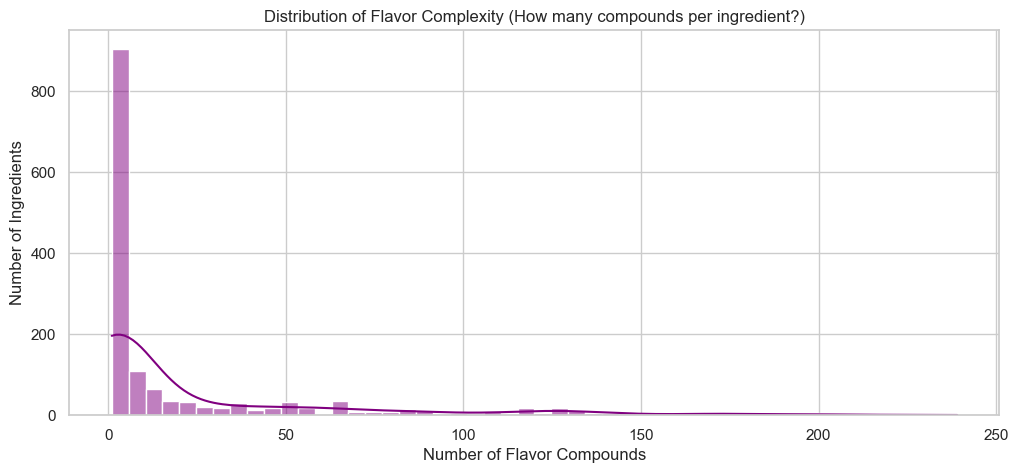

In [4]:

import matplotlib.pyplot as plt
import seaborn as sns


flavor_complexity = edges_df.groupby('ingredient_id').size().reset_index(name='compound_count')


complex_ingredients = pd.merge(flavor_complexity, ingr_df, on='ingredient_id', how='inner')


complex_ingredients = complex_ingredients.sort_values(by='compound_count', ascending=False)

print("\nTop 10 Most Flavor-Complex Ingredients:")

display(complex_ingredients[['ingredient_name', 'category', 'compound_count']].head(10))


plt.figure(figsize=(12, 5))
sns.histplot(complex_ingredients['compound_count'], bins=50, kde=True, color='purple')
plt.title('Distribution of Flavor Complexity (How many compounds per ingredient?)')
plt.xlabel('Number of Flavor Compounds')
plt.ylabel('Number of Ingredients')
plt.show()

In [7]:
#fuzzy matching
import pandas as pd
import difflib


ingr_df['clean_name'] = ingr_df['ingredient_name'].str.lower().str.replace('_', ' ').str.strip()
foodb_foods['clean_name'] = foodb_foods['name'].str.lower().str.strip()


exact_matches = pd.merge(ingr_df, foodb_foods, on='clean_name', how='inner')
print(f"Exact Matches (after removing underscores): {len(exact_matches)}")

unmatched_flavor_ingr = ingr_df[~ingr_df['clean_name'].isin(exact_matches['clean_name'])]['clean_name'].tolist()
foodb_names_list = foodb_foods['clean_name'].tolist()

def get_fuzzy_match(word, choices, cutoff=0.80):

    matches = difflib.get_close_matches(word, choices, n=1, cutoff=cutoff)
    return matches[0] if matches else None

print(f"\nRunning fuzzy matching on {len(unmatched_flavor_ingr)} remaining ingredients...")


fuzzy_matches = []
for name in unmatched_flavor_ingr:
    best_match = get_fuzzy_match(name, foodb_names_list)
    if best_match:
        fuzzy_matches.append({'flavor_name': name, 'foodb_name': best_match})

fuzzy_df = pd.DataFrame(fuzzy_matches)
print(f"Fuzzy algorithm successfully rescued {len(fuzzy_df)} additional ingredients")

fuzzy_with_groups = fuzzy_df.merge(
    foodb_foods[['clean_name', 'food_group']],
    left_on='foodb_name',
    right_on='clean_name',
    how='left'
 )

matched_ingredients = pd.concat([
    exact_matches[['clean_name', 'food_group']],
    fuzzy_with_groups[['foodb_name', 'food_group']].rename(columns={'foodb_name': 'clean_name'})
], ignore_index=True)

# Calculate Final Feasibility
total_matches = len(exact_matches) + len(fuzzy_df)
total_flavor_ingr = len(ingr_df)
match_percentage = (total_matches / total_flavor_ingr) * 100

print(f"Total Ingredients Bridged: {total_matches} / {total_flavor_ingr}")
print(f"Final Match Rate: {match_percentage:.2f}%")

if match_percentage > 30:
    print("Feasibility proven")

Exact Matches (after removing underscores): 201

Running fuzzy matching on 1330 remaining ingredients...
Fuzzy algorithm successfully rescued 114 additional ingredients
Total Ingredients Bridged: 315 / 1531
Final Match Rate: 20.57%


C:\Users\benka\AppData\Local\Temp\ipykernel_14816\3654139052.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=group_counts.index, x=group_counts.values, palette='viridis')


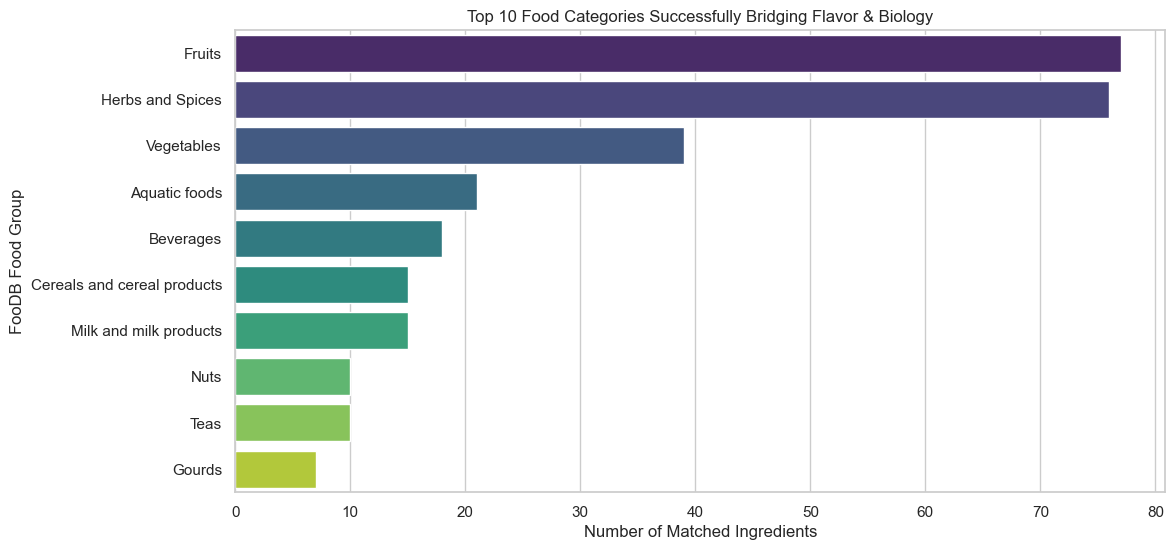

In [8]:

plt.figure(figsize=(12, 6))
group_counts = matched_ingredients['food_group'].value_counts().head(10)
sns.barplot(y=group_counts.index, x=group_counts.values, palette='viridis')
plt.title('Top 10 Food Categories Successfully Bridging Flavor & Biology')
plt.xlabel('Number of Matched Ingredients')
plt.ylabel('FooDB Food Group')
plt.show()